In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import gamma, norm
import os
import random
from scipy.stats import gamma, chi2
import scipy.stats as stats
from scipy.stats import invgamma
import math
from scipy.special import expit,logit #sigmoid
from sklearn.mixture import GaussianMixture
import nbimporter
import cepairsimplementation as ce
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [2]:
#aid functions

def derivative_polyfit(time, samples, r, poly_degree=2):
    """
    Estimate the derivative by fitting a polynomial to the last r samples and 
    differentiating the fitted polynomial at the most recent time.

    Parameters:
        time (list or np.array): Timestamps corresponding to each sample in chronological order,
                                 with the most recent sample at the end.
        samples (list or np.array): Data points corresponding to the time points.
        r (int): The number of recent samples to use for the fit.
        poly_degree (int): Degree of the polynomial to fit (default is 2).

    Returns:
        float: The estimated derivative at the current time.

    Raises:
        ValueError: If the number of samples or time points is less than r, 
                    or if the lengths of time and samples do not match.
    """
    if len(samples) < r or len(time) < r:
        raise ValueError(f"At least {r} samples are required.")
    if len(time) != len(samples):
        raise ValueError("Time and samples vectors must have the same length.")
    
    # Use the last r samples.
    y = np.array(samples[-r:])
    t_recent = np.array(time[-r:])
    
    # Shift the time vector so that the most recent sample corresponds to t = 0.
    t_shifted = t_recent - t_recent[-1]
    
    # Fit a polynomial of the given degree to the (t_shifted, y) data.
    coeffs = np.polyfit(t_shifted, y, poly_degree)
    
    # Compute the derivative of the polynomial.
    poly_deriv = np.polyder(coeffs)
    
    # Evaluate the derivative at t = 0 (the most recent sample).
    deriv_at_zero = np.polyval(poly_deriv, 0)
    
    return deriv_at_zero

def split_vectors(theta, psi):
    # Calculate the minimum size of each split, which is 5% of the vectors
    min_split_size_theta = int(np.ceil(0.05 * len(theta)))
    
    # Number of splits based on the length of the vectors
    num_splits = np.random.randint(2, 3)
    
    # Calculate the split sizes for both vectors
    split_sizes_theta = []
    
    remaining_theta = len(theta)
    
    for i in range(num_splits - 1):
        # Randomly distribute the remaining elements for both vectors
        split_size_theta = np.random.randint(min_split_size_theta, remaining_theta - (num_splits - i - 1) * min_split_size_theta)
        
        split_sizes_theta.append(split_size_theta)
        
        remaining_theta -= split_size_theta
    
    # Add the last split size to use up all the remaining elements
    split_sizes_theta.append(remaining_theta)
    
    # Shuffle the split sizes for randomness
    np.random.shuffle(split_sizes_theta)
    
    # Split the vectors according to the calculated sizes
    pieces_theta = []
    pieces_psi = []
    
    start_idx_theta = 0
    start_idx_psi = 0
    
    for size_theta in split_sizes_theta:
        end_idx_theta = start_idx_theta + size_theta
        
        pieces_theta.append(theta[start_idx_theta:end_idx_theta])
        pieces_psi.append(psi[start_idx_theta:end_idx_theta])
        
        start_idx_theta = end_idx_theta
    
    return pieces_theta, pieces_psi

def minmax(data):
    return (data - data.min()) / (data.max() - data.min())

def rescale_distribution(points, target_mean, target_variance):
    """
    Rescales a distribution to have a new mean and variance while keeping its shape.
    
    Parameters:
        points (array-like): Original vector of points.
        target_mean (float): Desired mean of the new distribution.
        target_variance (float): Desired variance of the new distribution.
    
    Returns:
        numpy.ndarray: New vector of points after rescaling.
    """
    # Convert input to a numpy array in case it's not already one.
    points = np.array(points)
    
    # Compute the original mean and variance.
    orig_mean = np.mean(points)
    orig_variance = np.var(points)
    
    # Check for zero variance to avoid division by zero.
    if orig_variance == 0:
        raise ValueError("The original variance is zero; cannot rescale a constant distribution.")
    
    # Calculate the scaling factor as the ratio of the standard deviations.
    scaling_factor = np.sqrt(target_variance / orig_variance)
    
    # Apply the affine transformation.
    new_points = (points - orig_mean) * scaling_factor + target_mean
    
    return new_points

def sample_biased(a, b):
    """
    Sample a number from the interval [a, b] with bias such that 
    values closer to a are more likely. This uses the beta distribution
    with parameters (1, 2), which has a linearly decreasing density.
    """
    z = random.betavariate(1, 2)
    return a + (b - a) * z

def compute_barycentric_weights(x):
    n = len(x)
    w = [1.0] * n
    for j in range(n):
        for i in range(n):
            if i != j:
                w[j] /= (x[j] - x[i])
    return w

def poly_solve(x, y, xi):
    w=compute_barycentric_weights(x)
    # If xi equals one of the nodes, return the corresponding value immediately.
    for j, xj in enumerate(x):
        if xi == xj:
            return y[j]
    numerator = 0
    denominator = 0
    for xj, yj, wj in zip(x, y, w):
        term = wj / (xi - xj)
        numerator += term * yj
        denominator += term
    return numerator / denominator

def poly_solve2(coefs, x):
    result = 0
    for coef in coefs:
        result = result * x + coef
    return result

def compute_power_function(xi, yi, x, tol=1e-10, max_iter=1000):
    """
    Given two points (xi[0], yi[0]) and (xi[1], yi[1]),
    finds parameters delta and psi such that:
    
        y = (x + delta)^psi
        
    passes through both points, i.e.,
        yi[0] = (xi[0] + delta)^psi
        yi[1] = (xi[1] + delta)^psi

    It then returns the value of y at the provided x.
    
    Parameters:
      xi : list or tuple of two x-coordinates [x0, x1]
      yi : list or tuple of two y-coordinates [y0, y1]
      x  : the x-value at which to evaluate the power function
      
    Returns:
      y  : the computed y-value at x, i.e. (x+delta)^psi
      
    Notes:
      This implementation uses a bisection method to solve for psi.
      It catches OverflowError exceptions when evaluating exponentials.
    """
    x0, x1 = xi[0], xi[1]
    y0, y1 = yi[0], yi[1]
    
    # Define function f(psi) = y1^(1/psi) - y0^(1/psi) - (x1 - x0)
    def f(psi):
        try:
            term1 = math.exp(math.log(y1) / psi)
        except OverflowError:
            term1 = float('inf')
        try:
            term0 = math.exp(math.log(y0) / psi)
        except OverflowError:
            term0 = float('inf')
        return term1 - term0 - (x1 - x0)
    
    # Set initial bounds for psi. 
    # A lower bound that is too small may cause overflow; hence, we choose 1e-3.
    low, high = 1e-3, 1e6
    
    # Check that the initial bounds bracket the root.
    if f(low) < 0:
        raise ValueError("f(low) < 0; adjust the lower bound or check input values.")
    if f(high) > 0:
        raise ValueError("f(high) > 0; adjust the upper bound or check input values.")
    
    iter_count = 0
    psi = None
    while iter_count < max_iter:
        mid = (low + high) / 2.0
        f_mid = f(mid)
        if abs(f_mid) < tol:
            psi = mid
            break
        # Choose the subinterval where the sign change occurs.
        if f(low) * f_mid < 0:
            high = mid
        else:
            low = mid
        iter_count += 1
    
    if psi is None:
        psi = (low + high) / 2.0  # fallback if tolerance was not met

    # Compute delta from the relation: x0 + delta = y0^(1/psi)
    try:
        base = math.exp(math.log(y0) / psi)
    except OverflowError:
        raise OverflowError("Overflow encountered when computing delta. Check input values.")
    delta = base - x0
    
    # Return the computed y-value at x:
    return math.pow(x + delta, psi)

def integrated_brownian_motion(x, method="trapezoidal"):
    """
    Compute the integrated Brownian motion at the time points specified in x.
    
    The integrated Brownian motion is defined as:
      Y(t) = ∫_0^t W(s) ds,
    where W(s) is a standard Brownian motion.
    
    Parameters:
        x (array_like): A vector of time points (not necessarily equally spaced).
        method (str): Numerical integration method ("left" or "trapezoidal").
                      "trapezoidal" uses the trapezoidal rule,
                      "left" uses a left Riemann sum.
    
    Returns:
        y (np.ndarray): The integrated Brownian motion evaluated at each x.
    """
    # Ensure x is a NumPy array and sort it
    x = np.sort(np.array(x))
    n = len(x)
    
    # Simulate standard Brownian motion at the points in x
    W = np.zeros(n)
    for i in range(1, n):
        dt = x[i] - x[i - 1]
        dW = np.sqrt(dt) * np.random.randn()
        W[i] = W[i - 1] + dW
    
    # Integrate W over time to obtain Y using the chosen method
    y = np.zeros(n)
    if method == "left":
        # Left Riemann sum: Use the value of W at the left endpoint of each subinterval
        for i in range(1, n):
            dt = x[i] - x[i - 1]
            y[i] = y[i - 1] + W[i - 1] * dt
    elif method == "trapezoidal":
        # Trapezoidal rule: Average the endpoints of each subinterval
        for i in range(1, n):
            dt = x[i] - x[i - 1]
            y[i] = y[i - 1] + 0.5 * (W[i - 1] + W[i]) * dt
    else:
        raise ValueError("Unknown integration method. Use 'left' or 'trapezoidal'.")
    
    return y

def getinvgammaparams(expected,variance):
    a=expected**2 / variance + 2
    return (a , expected * (a - 1))

def sample_inv_gamma(expected, variance):
    """
    Sample from an inverse gamma distribution given the expected value (mean) and variance.
    
    For an inverse gamma distribution with shape parameter 'a' and scale parameter 'b':
        expected = b / (a - 1)  (for a > 1)
        variance = b^2 / ((a - 1)^2 * (a - 2))  (for a > 2)
    
    The parameters are calculated as:
        a = expected^2 / variance + 2
        b = expected * (a - 1)
    
    Parameters:
        expected (float): The expected value (mean) of the distribution.
        variance (float): The variance of the distribution.
        
    Returns:
        float: A random sample from the inverse gamma distribution.
    """
    a = expected**2 / variance + 2
    b = expected * (a - 1)

    return stats.invgamma(a, scale=b).rvs()

def random_zoom_interval():
    """
    Returns a tuple (x_min, x_max) representing a random subinterval of [0, 1].
    
    The length L = x_max - x_min is chosen uniformly between 0.1 and 1.
    Then, x_min is chosen uniformly in the interval [0, 1 - L] so that x_max = x_min + L
    is at most 1.
    """
    # Step 1: Choose a random length L between 0.1 and 1.
    L = random.uniform(0.1, 0.8)
    
    # Step 2: Choose a random starting point ensuring that x_max = x_min + L <= 1.
    x_min = random.uniform(0, 1 - L)
    x_max = x_min + L
    
    return x_min, x_max


def fit_continuous_mixture(data, n_components=3, random_state=None, lower=0, upper=2000):
    """
    Fit a 1D Gaussian Mixture to continuous data and return
    a truncated distribution-like object with .rvs() and .plot_pdf() methods.

    Parameters
    ----------
    data : array-like
        Observed continuous datapoints.
    n_components : int
        Number of Gaussian components to fit.
    random_state : int or None
        Random seed for reproducibility.
    lower : float
        Minimum allowed sample value (inclusive).
    upper : float
        Maximum allowed sample value (inclusive).

    Returns
    -------
    dist : object
        Has .rvs(size=None) and .plot_pdf().
    """
    X = np.asarray(data).reshape(-1, 1)
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=random_state
    ).fit(X)

    weights = gmm.weights_.flatten()
    means = gmm.means_.flatten()
    covs = np.array([cov.flatten()[0] for cov in gmm.covariances_])  # 1D

    class MixtureDist:
        def __init__(self, weights, means, covs, lower, upper):
            self.weights = weights
            self.means = means
            self.covs = covs
            self.lower = lower
            self.upper = upper

        def rvs(self, size=None):
            size = 1 if size is None else size
            samples = []
            while len(samples) < size:
                remaining = size - len(samples)
                comps = np.random.choice(len(self.weights), size=remaining, p=self.weights)
                draws = np.random.normal(
                    loc=self.means[comps],
                    scale=np.sqrt(self.covs[comps])
                )
                valid = draws[(draws >= self.lower) & (draws <= self.upper)]
                samples.extend(valid.tolist())
            return samples[0] if size == 1 else np.array(samples)

        def plot_pdf(self, x_range=None, num_points=1000, show_components=True, ax=None):
            stds = np.sqrt(self.covs)
            xmin, xmax = x_range if x_range else (self.lower, self.upper)
            x = np.linspace(xmin, xmax, num_points)
            pdf = np.zeros_like(x)

            for weight, mean, std in zip(self.weights, self.means, stds):
                # Compute component PDF but truncate values outside bounds
                component_pdf = weight * norm.pdf(x, mean, std)
                pdf += component_pdf
                if show_components:
                    if ax is None:
                        plt.plot(x, component_pdf, '--', alpha=0.5)
                    else:
                        ax.plot(x, component_pdf, '--', alpha=0.5)

            if ax is None:
                plt.plot(x, pdf, label='Mixture PDF', color='black')
                plt.title("Truncated Gaussian Mixture PDF")
                plt.xlabel("x")
                plt.ylabel("Density")
                plt.legend()
                plt.grid(True)
                plt.show()
            else:
                ax.plot(x, pdf, label='Mixture PDF', color='black')
                ax.set_title("Truncated Gaussian Mixture PDF")
                ax.set_xlabel("x")
                ax.set_ylabel("Density")
                ax.legend()
                ax.grid(True)
                return ax

    return MixtureDist(weights, means, covs, lower, upper)

In [3]:
def sample_latent(samples, dist,latent=2):
    # Hyperparameters for each distribution
    # Uniform distribution parameters
    uni_low = 0
    uni_high = 1

    # Normal distribution parameters
    norm_loc = 1
    norm_scale = latent/100

    # Gamma distribution parameters (used in "twenty" case)
    gamma_a = 2
    gamma_scale = 0.5

    # Rayleigh distribution parameters
    raleigh_scale = latent  # Adjust this parameter as needed

    # Chi-square distribution parameters
    chi_df = latent      # degrees of freedom; adjust as needed

    # Generate samples based on the chosen distribution
    if dist == "uni":
        result = np.random.uniform(uni_low, uni_high, size=samples)
    elif dist == "normal":
        result = np.random.normal(norm_loc, norm_scale, size=samples)
    elif dist == "gamma":
        result = gamma.rvs(a=gamma_a, scale=gamma_scale, size=samples)
    elif dist == "raleigh":
        result = np.random.rayleigh(raleigh_scale, size=samples)
    elif dist == "chi square":
        result = chi2.rvs(df=chi_df, size=samples)
    else:
        result = np.nan

    result = minmax(result)
    return result

In [4]:
def apply_noise(ymed, level=0.1, noise_type='both'):
    """
    Add multiplicative and/or additive Gaussian noise to a signal.

    Parameters
    ----------
    ymed : array-like
        Input signal (1D or ND).
    level : float, optional
        Noise‑to‑signal power ratio. Defines noise variance as
        level * signal power. Default is 0.1.
    noise_type : {'both', 'multiplicative', 'additive'}, optional
        Which noise to apply:
        - 'both'         : apply multiplicative AND additive noise (default)
        - 'multiplicative': only multiplicative noise
        - 'additive'     : only additive noise

    Returns
    -------
    y_noisy : ndarray
        Noisy signal of same shape as `ymed`.
    """
    y = np.asarray(ymed, dtype=float)
    signal_power = np.mean(y**2)
    y_noisy = y.copy()

    if noise_type not in {'both', 'multiplicative', 'additive'}:
        raise ValueError("noise_type must be one of 'both', 'multiplicative', or 'additive'")

    # Multiplicative noise
    if noise_type in {'both', 'multiplicative'}:
        # ε ~ N(0, level)
        sigma_mul = np.sqrt(level)
        eps_mul = np.random.normal(loc=0.0, scale=sigma_mul, size=y.shape)
        y_noisy = y_noisy * (1 + eps_mul)

    # Additive noise
    if noise_type in {'both', 'additive'}:
        # n ~ N(0, level * signal_power)
        sigma_add = np.sqrt(level * signal_power)
        n_add = np.random.normal(loc=0.0, scale=sigma_add, size=y.shape)
        y_noisy = y_noisy + n_add

    return y_noisy

In [5]:
#MAIN FUNCTIONS
def construct_linear(x,start, end, psi1,psi2):
    return psi1+(psi2-psi1)*(x-start)/(end-start)

#hyper-parameters are written inline
def sample_var_aux(vars,times,r,dt,auxs,potencia=2,imp="sig"):
    #code
    gamma_mean=vars[0]
    gamma_std=gamma_mean/2
    sig=1/potencia
    a,scale=getinvgammaparams(gamma_mean,gamma_std)
    if len(vars)==1:
        da=0
    else:
        da=derivative_polyfit(times,auxs,r)
   
    mean=auxs[-1]+da*dt
    std=np.sqrt((dt**potencia)/sig)
    if imp=="sig":
        aux=np.random.normal(mean,std)
        var=invgamma.ppf(expit(aux), a=a, scale=scale)
    if imp=="exp1":
        aux=np.random.normal(mean,std)
        var=np.exp(aux)
    if imp=="exp2":
        var= sample_inv_gamma(np.exp(mean),std**2)
        aux=np.log(var)
    return var,aux
    

def get_start_aux(var,std_diviser=2):
    #code
    gamma_mean=var
    gamma_std=gamma_mean/std_diviser
    imp="sig"

    a,scale=getinvgammaparams(gamma_mean,gamma_std)
    if imp=="sig":
        aux=logit(invgamma.cdf(var, a=a, scale=scale))
    if imp=="exp1":
        aux=0
    if imp=="exp2":
        aux=0
    return aux

def sample_mean(means,times, r,dt,potencia=1):

    #code
    sig=1/potencia
    if len(means)==1:
        dm=1
    else:
        dm=derivative_polyfit(times, means,r)
    mean=means[-1]+dm*dt
    std=np.sqrt((dt**potencia)/sig)
    return np.random.normal(mean,std)

def linear(x,distpsi,gamma_mean=0.3,std_diviser=2):
    #code
    start_mean=0
    gamma_var=gamma_mean/std_diviser
    angle=np.random.uniform(0,2*math.pi)
    end_mean=math.tan(angle)
    start_var=sample_inv_gamma(gamma_mean,gamma_var)
    end_var=sample_inv_gamma(gamma_mean,gamma_var)


    #samples psis
    psi=sample_latent(len(x),distpsi)

    psi1=rescale_distribution(psi,start_mean,start_var)
    psi2=rescale_distribution(psi,end_mean,end_var)

    y=construct_linear(x,min(x),max(x),psi1,psi2)
    #print("s-e",start_mean,start_var,end_mean,end_var)
    #plt.plot(x,y,'.')
    #plt.show()
    if random.random()>0.5:
        y=-y
    return y



#timeseries    
def mix(x,distpsi,max_splits=4,gamma_mean=0.3,std_diviser=2,potencia_mean=3,potencia=3,imp="sig"):

    #code
    gamma_var=gamma_mean/std_diviser
    splits=np.sort(np.random.uniform(0,1,size=np.random.choice(1+np.array(range(max_splits)))))
    splits = np.concatenate(([0], splits, [1]))  # Correct way to combine

    psi=sample_latent(len(x),distpsi) #latent variable

    psis=[]
    means=[0]
    vars=[sample_inv_gamma(gamma_mean,gamma_var)]
    psis.append(rescale_distribution(psi,means[0],vars[0]))
    y=[]
    for j in range(len(splits)-1):
        inds=(x >= splits[j]) & (x <= splits[j+1])
        means.append(sample_mean([means[-1]],1,1,splits[j+1]-splits[j],potencia_mean))
        vars.append(sample_var_aux([vars[-1]],1,1,splits[j+1]-splits[j],[get_start_aux(vars[-1])],potencia,imp)[0])
        psis.append(rescale_distribution(psi,means[j+1],vars[j+1]))
        y.extend(construct_linear(x[inds],splits[j],splits[j+1],psis[j][inds],psis[j+1][inds]))
    
    #print("means",means)
    #plt.plot(x,y,'.')
    #plt.plot(splits,means)
    #plt.show()
    
    return np.array(y)
            
def exp(x, distpsi, prior1_meta=[3,1.5,0.3,0.1],prior2_meta=[1,0.05]):
    #code
    prior1_mean_mean=prior1_meta[0]
    prior1_mean_var=prior1_meta[1]
    prior1_var_mean=prior1_meta[2]
    prior1_var_var=prior1_meta[3]
    prior2_mean_mean=prior2_meta[0]
    prior2_mean_var=prior2_meta[1]

    psi1=sample_latent(len(x),distpsi) #multiplier
    psi2=sample_latent(len(x),distpsi) #shifter

    #sampling psi1 for this specific example:
    psi1_mean=np.random.normal(prior1_mean_mean,prior1_mean_var)
    psi1_var=np.random.uniform(prior1_var_mean-prior1_var_var,prior1_var_mean+prior1_var_var)
    psi1=rescale_distribution(psi1,psi1_mean,psi1_var)

    #sampling psi2 for this specific example:
    psi2_mean=np.random.normal(prior2_mean_mean,prior2_mean_var)
    psi2=rescale_distribution(psi2,psi2_mean,0)

    #function
    y=np.exp(psi1*(x-psi2))

    if random.random()<0.5:
        x=-x
    if random.random()<0.5:
        y=-y
    #plt.plot(x,y,'.')
    #plt.show()
    return y

def inv(x, distpsi,psi1_meta=[1.2,0.4,0.1,0.05],psi2_meta=[0.3,0.15]):
    #code
    psi1=sample_latent(len(x),distpsi) #multiplier
    psi2=sample_latent(len(x),distpsi) #shifter

    #sampling psi1 for this specific example:
    psi1_mean=np.random.normal(psi1_meta[0],psi1_meta[1])
    psi1_var=np.random.uniform(psi1_meta[2]-psi1_meta[3],psi1_meta[2]+psi1_meta[3])
    psi1=rescale_distribution(psi1,psi1_mean,psi1_var)

    #sampling psi2 for this specific example:
    psi2_mean=np.random.normal(psi2_meta[0],psi2_meta[1])
    psi2=np.abs(rescale_distribution(psi2,psi2_mean,0))

    #func
    #print(psi2_mean,min(psi2))
    y=psi1+1/(x+psi2)

    if random.random()<0.5:
        x=-x
    if random.random()<0.5:
        y=-y

    #plt.plot(x,y,'.')
    #plt.show()
    return y

#como adicionar ruido sem ser como ruido? podemos incluir o psi aqui? sera?
def brown(x,distpsi,r=5,gamma_mean=0.3,std_diviser=2,potencia_mean=3,potencia=3,imp="sig"):
    #code:
    gamma_var=gamma_mean/std_diviser
    psi=sample_latent(len(x),distpsi)
    x=np.sort(x)
    x=x
    y=[]
    times=[]
    times.append(x[0])
    means=[0]
    vars=[sample_inv_gamma(gamma_mean,gamma_var)]
    auxs=[get_start_aux(vars[-1])]
    y.append(rescale_distribution(psi,means[-1],vars[-1])[0])
    for i in range(len(x)-1):
        if i==0:
            means.append(sample_mean([means[-1]],times, 1,x[1]-x[0],potencia_mean))
            var,aux=sample_var_aux(vars,times, 1,x[1]-x[0],auxs,potencia,imp)
            vars.append(var)
            auxs.append(aux)
        else:
            dt=x[i+1]-x[i]
            means.append(sample_mean(means,times, min(i+1,r),dt,potencia_mean))
            var,aux=sample_var_aux(vars,times, min(i+1,r),dt,auxs,potencia,imp)
            vars.append(var)
            auxs.append(aux)
        times.append(x[i+1])
        y.append(rescale_distribution(psi,means[-1],vars[-1])[i+1])
    return y

def log(x,distpsi,psi_meta=[0.0001,0.3]):
    #code
    psi=sample_latent(len(x),distpsi) #multiplier   
    #sampling psi for this specific example:
    psi_mean=sample_biased(psi_meta[0],psi_meta[1])
    psi_var=psi_mean
    psi=np.abs(rescale_distribution(psi,psi_mean,psi_var))

    #function
    y=np.log(psi+x)

    if random.random()<0.5:
        y=-y
    
    return y

def poly1(x,distpsi,max_order=5,gamma_mean=0.3,std_diviser=2,potencia_mean=3,potencia=3,imp="sig"): 
    #code
    gamma_var=gamma_mean/std_diviser
    splits=np.sort(np.random.uniform(0,1,size=np.random.choice(1+np.array(range(max_order-1)))))
    splits = np.concatenate(([0], splits, [1]))
    
    psi=sample_latent(len(x),distpsi) #latent variable\\
    
    means=[0]
    vars=[sample_inv_gamma(gamma_mean,gamma_var)]
    psis=[rescale_distribution(psi,means[0],vars[0])]
    for i in range(len(splits)-1):
        means.append(sample_mean([means[-1]],1,1,splits[i+1]-splits[i],potencia_mean))
        vars.append(sample_var_aux([vars[-1]],1,1,splits[i+1]-splits[i],[get_start_aux(vars[-1])],potencia,imp)[0])
        psis.append(rescale_distribution(psi,means[-1],vars[-1]))
    psis=np.array(psis)
    
    y=np.array([poly_solve(splits,psis[:,i],x[i]) for i in range(len(x))])
    return y


def power(x, distpsi,psi_meta=[-4,4]):
    #code
    psi=sample_latent(len(x),distpsi) #multiplier   
    #sampling psi for this specific example:
    psi_mean=np.random.uniform(psi_meta[0],psi_meta[1])
    psi_var=np.abs(psi_mean)/10
    psi=rescale_distribution(psi,psi_mean,psi_var)
    
    psi2=random_zoom_interval()
    #function
    x_psied=x*(psi2[1]-psi2[0]) + psi2[0]
    y=x_psied**psi
    return y

In [4]:

def create_dataset(func,disttheta,distpsi,eps,N,dist_samples,**kwargs):
    kwargs_str = "_"+", ".join(f"{k}={v}" for k, v in kwargs.items())
    #pre pop
    for i in range(N):
        samples=dist_samples.rvs()
        samples=max(3,int(samples)) #to ensure everything runs smoothly
        #prior on x (theta)
        theta=sample_latent(samples,disttheta)
        x=minmax(seedN.normal(theta,eps,size=samples))
        x=np.sort(x)

        noise = kwargs.pop('noise', False)
        noise_level = kwargs.pop('noise_level', 0.1)
        #func
        if func=="linear":
            ymed=linear(x,distpsi,**kwargs)
        elif func=="exp":
            ymed=exp(x,distpsi,**kwargs)
        elif func=="inv":
            ymed=inv(x,distpsi,**kwargs)
        elif func=="mix":
            ymed=mix(x,distpsi,**kwargs)
        elif func=="brown":
            ymed=brown(x,distpsi,**kwargs)
        elif func=="poly1":
            ymed=poly1(x,distpsi,**kwargs)
        elif func=="log":
            ymed=log(x,distpsi,**kwargs)
        elif func=="power":
            ymed=power(x,distpsi,**kwargs)

        
        if noise:
            ymed=apply_noise(ymed,level=noise_level)

        y=minmax(np.random.normal(ymed,eps))  
        #y=ymed      
        plt.figure()
        plt.plot(x, y,'.')  # Example plot
        plt.xlabel("X")
        plt.ylabel("Y")
        # Save the plot as a PNG file in the folder
        folder=f"generate_scenarios/exchangeable_{func}_{disttheta}_{distpsi}_new_{kwargs_str}"
        os.makedirs(folder, exist_ok=True)
        folder_txt=f"generate_txt/exchangeable_{func}_{disttheta}_{distpsi}_new_{kwargs_str}"
        os.makedirs(folder_txt, exist_ok=True)
        plt.savefig(f"{folder}/plot_{i+1}.png")
        plt.savefig(f"allfigs/exchangeable_{func}_{disttheta}_{distpsi}{kwargs_str}_plot_{i+1}.png")
        plt.close()  # Close the plot to avoid overlapping in next iteration
        np.savetxt(f'{folder_txt}/pair_{i+1}.txt', np.column_stack((x, y)), fmt='%f', delimiter=' ')


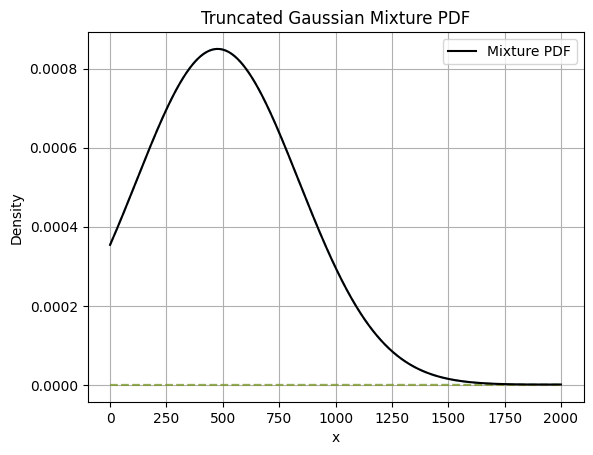

In [7]:
data,_=ce.getTuebingen()
lengths=[len(d[0]) for d in data]
dist_samples=fit_continuous_mixture(lengths)
dist_samples.plot_pdf()

In [10]:
disttheta="uni"
distpsi="uni"
func="brown" 

N=1
eps=0
seedN=np.random.default_rng(42)
create_dataset(func,disttheta,distpsi,eps,N,dist_samples,noise=True)

In [13]:
distthetas=["uni","normal","raleigh"]
distpsis=["uni","normal","raleigh"]
funcs=["linear","exp","inv","mix","brown","poly1","log","power"]
N=1
eps=0
seedN=np.random.default_rng(42)
data,_=ce.getTuebingen()
lengths=[len(d[0]) for d in data]
dist_samples=fit_continuous_mixture(lengths)
for func in funcs:
    for disttheta in distthetas:
        for distpsi in distpsis:
            create_dataset(func,disttheta,distpsi,eps,N,dist_samples,noise=True)

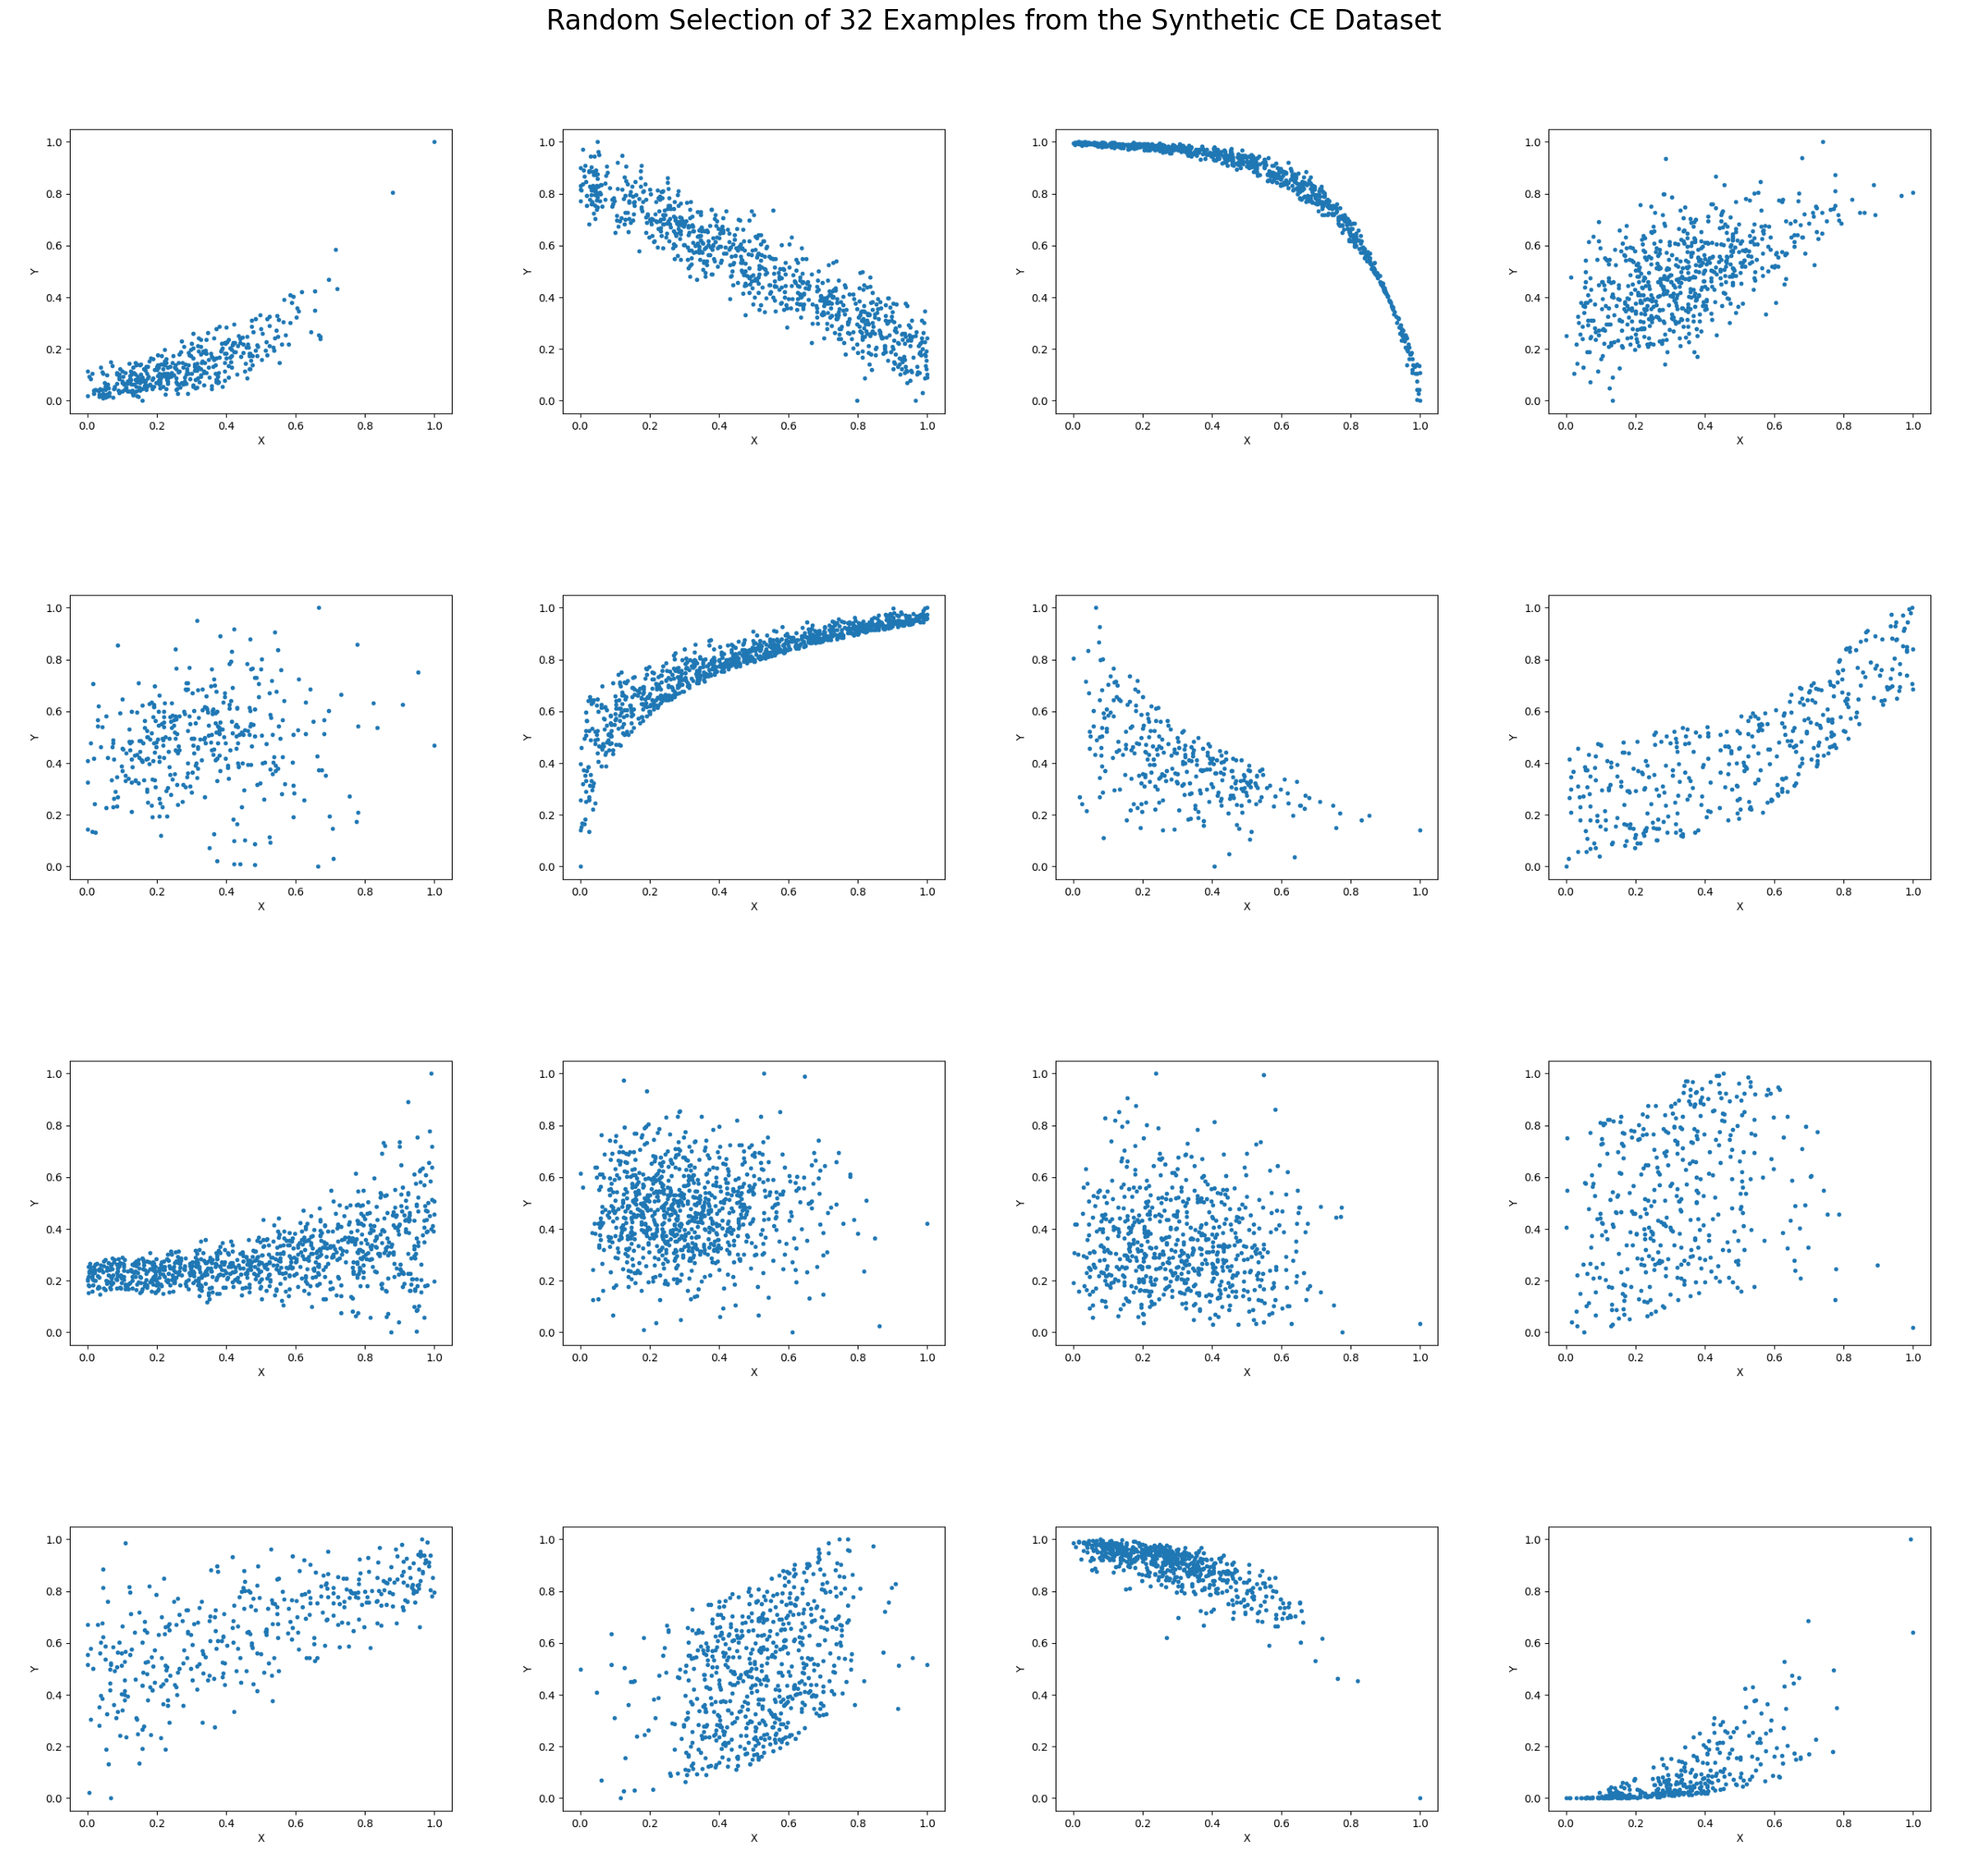

In [3]:

import matplotlib.image as mpimg

# Path to the folder containing images
folder_path = 'allfigs'

# Get a list of all files in the folder
all_files = os.listdir(folder_path)

# Filter out non-image files (optional, assuming files are jpg/png etc.)
image_files = [file for file in all_files if file.lower().endswith(('png', 'jpg', 'jpeg', 'gif', 'bmp'))]

# Select 32 random images
selected_images = random.sample(image_files, 16)

# Set up the plot with 8 rows and 4 columns, and reduce spacing
fig, axes = plt.subplots(4, 4, figsize=(24, 24), constrained_layout=True)

# Loop over the axes and selected images to display them
for i, ax in enumerate(axes.flat):
    # Load and display each image
    img_path = os.path.join(folder_path, selected_images[i])
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')  # Turn off axis labels
    ax.set_aspect('equal')

# Adjust spacing to reduce gaps between images

fig.suptitle('Random Selection of 32 Examples from the Synthetic CE Dataset', fontsize=24)
# Display the grid
plt.tight_layout(pad=0.0)  # Remove padding
plt.show()
